In [1]:
import src
import xarray as xr
import numpy as np

Importieren und Vorbereiten der Daten

In [9]:
from src import preprocessing
from src import snow_model
from src import land_mask

In [3]:
dataset = preprocessing.run_preprocessing(
        data_directory="./data/Model_Output_From_Harrison/Temp_Precip/nw_ur_150_07",
        file_pattern="nw_ur_150_07.cam.h0.*.nc",
        output_path="./data/interim/preprocessed/climate_data_processed.nc",
    )

Loading climate data files
Found: 360 files
First file: nw_ur_150_07.cam.h0.0005-01.nc
Last file: nw_ur_150_07.cam.h0.0034-12.nc
Calculating days in each month
Calculating total monthly precipitation
Converting temperature from Kelvin to Celsius
Saving processed data to ./data/interim/preprocessed/climate_data_processed.nc


Run Snow Model

In [5]:
snow_storage, snow_melt = snow_model.calculate_snow_dynamics(dataset.precip_mm_month.values, dataset.t_mean_celsius.values, dataset.days_in_month.values)

In [ ]:
def create_output_dataset(ds_original: xr.Dataset,
                          snow_storage: np.ndarray,
                          snow_melt: np.ndarray) -> xr.Dataset:
    """
    Create output dataset with snow model results.
    
    Parameters
    ----------
    ds_original : xr.Dataset
        Original dataset (for coordinates and metadata)
    snow_storage : np.ndarray
        Snow storage results, shape (time, lat, lon)
    snow_melt : np.ndarray
        Snow melt results, shape (time, lat, lon)
        
    Returns
    -------
    xr.Dataset
        Dataset containing original data plus snow variables
    """
    # Create DataArrays for snow variables
    snow_storage_da = xr.DataArray(
        snow_storage,
        dims=("time", "lat", "lon"),
        coords={
            "time": ds_original.time,
            "lat": ds_original.lat,
            "lon": ds_original.lon
        },
        name="SS",
        attrs={
            "units": "mm",
            "long_name": "Snow water equivalent storage",
            "description": f"Calculated with degree-day snow model "
        }
    )
    
    snow_melt_da = xr.DataArray(
        snow_melt,
        dims=("time", "lat", "lon"),
        coords={
            "time": ds_original.time,
            "lat": ds_original.lat,
            "lon": ds_original.lon
        },
        name="SM",
        attrs={
            "units": "mm",
            "long_name": "Snow melt",
            "description": f"Calculated with degree-day snow model "
        }
    )
    
    # Copy original dataset and add snow variables
    ds_out = ds_original.copy()
    ds_out["SS"] = snow_storage_da
    ds_out["SM"] = snow_melt_da
    
    # Add global attributes
    ds_out.attrs["snow_model_version"] = "1.0"
    ds_out.attrs["snow_model_description"] = "Degree-day snow accumulation and melt model"
    
    return ds_out

In [7]:
dataset = create_output_dataset(dataset, snow_storage, snow_melt)

Create and apply land mask

In [10]:
landmask = land_mask.create_land_mask(dataset, "./data/GADM/gadm_410.gpkg")

It takes some time to create the land mask so we save it for future use

In [11]:
land_mask.save_land_mask(landmask, "./data/interim/land_mask/land_mask_nw_ur_150_07.nc")  

Mask our dataset so that it only contains land masses

In [ ]:
dataset_masked = dataset.where(landmask)

Save Results

In [ ]:
dataset_masked.drop_vars("time_bnds").to_netcdf("./results/snow_model_output.nc") #drop time_bnds to avoid encoding issues

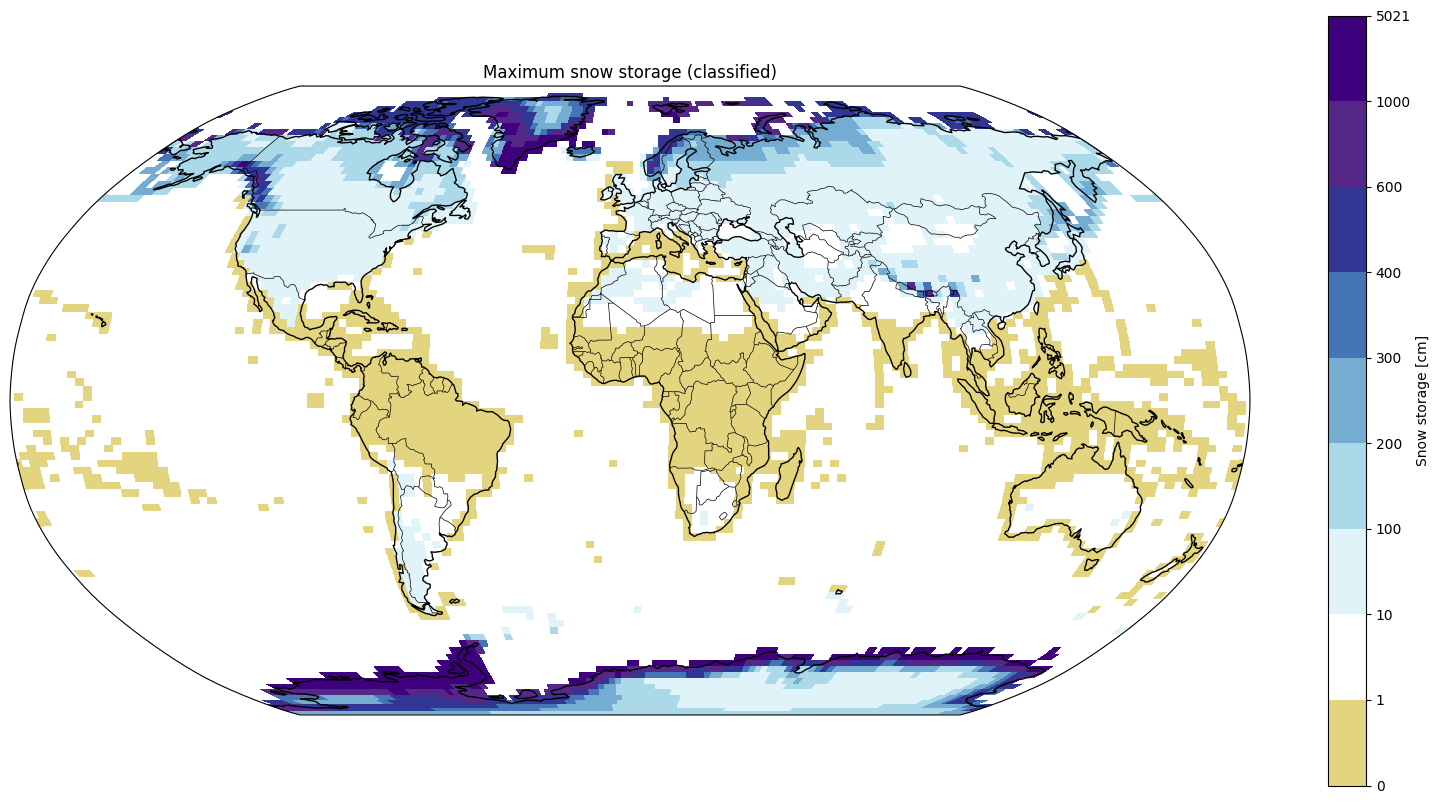

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors


data = dataset_masked["SS"].max(dim="time")
data = data/10


bin_edges = np.array([0, 1, 10, 100, 200, 300, 400, 600, 1000, data.max()])

# Anzahl Klassen
n_classes = len(bin_edges) - 1

# Diskrete Colormap erzeugen
#cmap = plt.get_cmap("YlGnBu", n_classes)
colors = [
    "#E3D47F", #0 - 0.1
    "#ffffff",  # 0–100        weiß
    "#e0f3f8",  # 100–1 000    sehr hellblau
    "#abd9e9",  # 1 000–2 000  hellblau
    "#74add1",  # 2 000–3 000  mittelblau
    "#4575b4",  # 3 000–4 000  dunkelblau
    "#313695",  # 4 000–6 000  sehr dunkelblau
    "#542788",  # 6 000–10 000 blau-lila
    "#3f007d",  # >10 000      lila
]

cmap = mcolors.ListedColormap(colors)

# Norm für Klassengrenzen
norm = mcolors.BoundaryNorm(bin_edges, ncolors=n_classes)

fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.Robinson())

im = data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Snow storage [cm]",
        "ticks": bin_edges  # letzte (inf) nicht anzeigen
    }
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Maximum snow storage (classified)")

plt.show()

#Darstellung verbessern evtl. grün als Farbe, wo nie Schnee liegt